# Multi-variable Linear Regression - Building Everything From Scratch

## Imports

In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd

In [2]:
import models
import toolkit

importlib.reload(models)
importlib.reload(toolkit)

from models import *
from toolkit import *

In [10]:
model_kit = ModelKit()
stat_kit = StatKit()

## Data Loading, Cleaning and Preparation

In [3]:
df = pd.read_csv("./datasets/Salary_Data.csv")

print("Original dataset size: ", len(df))

Original dataset size:  6704


### Dropping rows containing NAN value

In [4]:
df.isna().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [5]:
dropped_rows = df[df.isnull().any(axis=1)]
df = df.dropna()

print("Number of dropped rows: ", len(dropped_rows))

Number of dropped rows:  6


### Job Title Encoding

Job titles were converted to stable integer IDs.

The IDs follow alphabetical order so the mapping stays reproducible.

In [6]:
# Encode job titles into stable integer IDs (alphabetical order for reproducibility)
job_titles_clean = df.loc[df.index, "Job Title"].astype("string").str.strip()

job_title_categories = sorted(job_titles_clean.unique())
job_title_to_id = {title: idx for idx, title in enumerate(job_title_categories)}

df["Job_Title_ID"] = job_titles_clean.map(job_title_to_id).astype("Int64")

# Optional: view mapping table
job_title_mapping = (
    pd.DataFrame({"Job Title": job_title_categories})
    .assign(Job_Title_ID=lambda x: x.index)
)

print(f"Encoded {len(job_title_to_id)} unique job titles.")
job_title_mapping

Encoded 191 unique job titles.


,Job Title,Job_Title_ID
0,Account Manager,0
1,Accountant,1
2,Administrative Assistant,2
3,Back end Developer,3
4,Business Analyst,4
...,...,...
186,UX Designer,186
187,UX Researcher,187
188,VP of Finance,188
189,VP of Operations,189


### Gender Encoding

`Male` was mapped to `0` and `Female` to `1`.

Rows with unsupported gender values were removed before encoding.

In [7]:
gender_mapping = {
    "Male": 0,
    "Female": 1,
}

gender_clean = df["Gender"].astype("string").str.strip()
unsupported_gender_mask = ~gender_clean.isin(gender_mapping)

if unsupported_gender_mask.any():
    unsupported_gender_values = sorted(gender_clean[unsupported_gender_mask].dropna().unique())
    print(
        "Dropping",
        int(unsupported_gender_mask.sum()),
        "rows with unsupported Gender values:",
        unsupported_gender_values,
    )
    df = df.loc[~unsupported_gender_mask].copy()
    gender_clean = df["Gender"].astype("string").str.strip()

df["Gender_ID"] = gender_clean.map(gender_mapping).astype("Int64") # pyright: ignore[reportPossiblyUnboundVariable]

df[["Gender", "Gender_ID"]].drop_duplicates().sort_values("Gender_ID") # pyright: ignore[reportPossiblyUnboundVariable]

Dropping 14 rows with unsupported Gender values: ['Other']


,Gender,Gender_ID
0,Male,0
1,Female,1


### Education Encoding

Education levels were grouped into four numeric categories.

Equivalent text variants such as `Bachelor's` and `Bachelor's Degree` share the same code.

In [8]:
education_mapping = {
    "High School": 0,
    "Bachelor's Degree": 1,
    "Bachelor's": 1,
    "Master's Degree": 2,
    "Master's": 2,
    "PhD": 3,
    "phD": 3,
}

education_clean = df["Education Level"].astype("string").str.strip()
df["Education_Level_ID"] = education_clean.map(education_mapping).astype("Int64")

if df["Education_Level_ID"].isna().any():
    unexpected_education_values = sorted(
        education_clean[df["Education_Level_ID"].isna()].dropna().unique()
    )
    raise ValueError(
        f"Unmapped Education Level values found: {unexpected_education_values}"
    )

df[["Education Level", "Education_Level_ID"]].drop_duplicates().sort_values(
    ["Education_Level_ID", "Education Level"]
)

,Education Level,Education_Level_ID
2395,High School,0
0,Bachelor's,1
944,Bachelor's Degree,1
1,Master's,2
945,Master's Degree,2
2,PhD,3
5878,phD,3


In [9]:
df_clean = df[["Age", "Gender_ID", "Education_Level_ID", "Job_Title_ID", "Years of Experience", "Salary"]]

### Report Summary (Data Changes)

- Original loaded dataset shape: **(6704, 6)**.
- Removed **6 rows** containing missing values, resulting in **(6698, 6)**.
- During binary gender encoding (`Male=0`, `Female=1`), removed **14 rows** with unsupported `Gender` value (`Other`).
- Added encoded feature columns: `Job_Title_ID`, `Gender_ID`, and `Education_Level_ID`.
- Final engineered dataset shape (`df`): **(6684, 9)**.
- Final modeling subset shape (`df_clean`): **(6684, 6)**.
- **Features**: `Age`, `Gender_ID`, `Education_Level_ID`, `Job_Title_ID`, `Years_of_Experience`
- **Label**: `Salary`

## Correlation Matrix of Features

In [11]:
age = df_clean["Age"].to_numpy(dtype=np.float64)
gender = df_clean["Gender_ID"].to_numpy(dtype=np.float64)
education = df_clean["Education_Level_ID"].to_numpy(dtype=np.float64)
job_title = df_clean["Job_Title_ID"].to_numpy(dtype=np.float64)
experience = df_clean["Years of Experience"].to_numpy(dtype=np.float64)

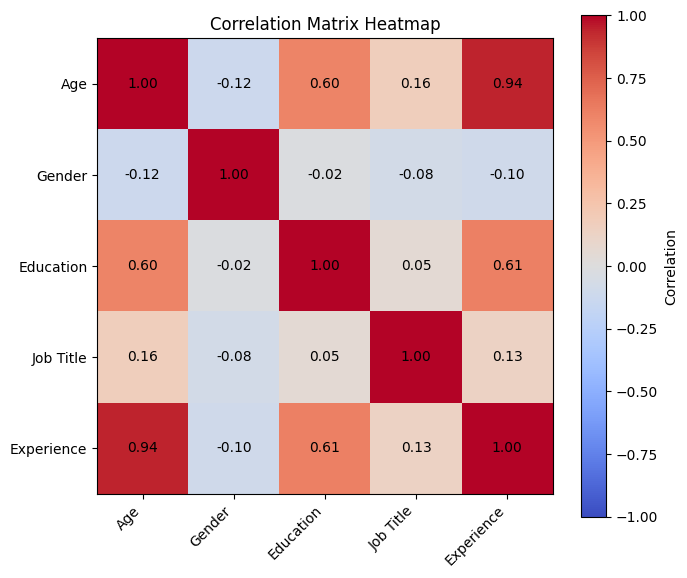

In [17]:
# 1) Build matrix
labels = ["Age", "Gender", "Education", "Job Title", "Experience"]
corr = stat_kit.corr_matrix([age, gender, education, job_title, experience])

# 2) Plot heatmap
plt.figure(figsize=(7, 6))
im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")

# 3) Axis labels
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

# 4) Optional: write correlation values inside cells
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

In [20]:
df_model = df_clean.drop(labels=["Age"], axis=1)